# <center> Renewable Energy World Wide : 1965~2022

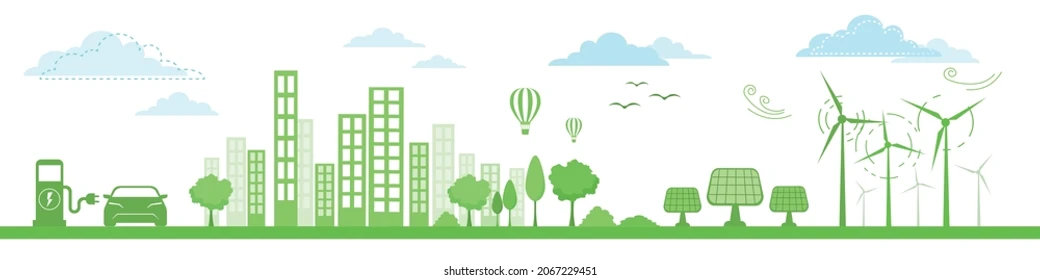

The Renewable Energy World Wide dataset is a **comprehensive collection of global renewable energy data from 1965 to 2022**.  
The dataset includes information on hydropower, wind, solar, biofuel, and geothermal energy production from around the world.  

Since the Industrial Revolution, **the energy mix of most countries across the world has become dominated by fossil fuels.**   
**This has major implications for the global climate, as well as for human health.**  

To reduce CO2 emissions and local air pollution, the world needs to rapidly shift towards low-carbon sources of energy – nuclear and renewable technologies.  

Renewable energy will play a key role in the decarbonization of our energy systems in the coming decades.  
 But how rapidly is our production of renewable energy changing? What technologies look most promising in transforming our energy mix?

#### Explaining the columns
- **Entity**: Refers to the country or region for which the renewable energy data is from
    
- **Code**: A three-letter code assigned to each country or region in the dataset

- **Year**: The year for which the renewable energy data is reported
    
- **Renewables (% equivalent primary energy)**: This column provides the percentage of equivalent primary energy that is derived from renewable sources for each country or region in the given year.

### Importing necessary libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.linear_model import LinearRegression

from IPython.display import display

### Loading and viewing the dataset

In [2]:
# Stop long decimals from cluttering the screen.

pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [3]:
# Load the dataset from a CSV file
# 'parse_dates' converts the 'Year' column into actual datetime objects for easier time-series analysis
data = pd.read_csv('./data/01 renewable-share-energy.csv', parse_dates=['Year']) # Parse dates in correct format

# Display a summary of the DataFrame (column names, non-null counts, and data types)
# This is useful for checking for missing values or incorrect data types
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5603 entries, 0 to 5602
Data columns (total 4 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   Entity                                    5603 non-null   str           
 1   Code                                      4292 non-null   str           
 2   Year                                      5603 non-null   datetime64[us]
 3   Renewables (% equivalent primary energy)  5603 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(2)
memory usage: 175.2 KB


In [4]:
# Preview the first 5 rows of the data in a formatted table
print("\n")
print("Displaying the first 5 rows")
display(data.head())

# Preview the last 5 rows of the data in a formatted table
print("\n")
print("Displaying the last 5 rows")
display(data.tail())



Displaying the first 5 rows


,Entity,Code,Year,Renewables (% equivalent primary energy)
0,Africa,NaN,1965-01-01,5.747
1,Africa,NaN,1966-01-01,6.122
2,Africa,NaN,1967-01-01,6.326
3,Africa,NaN,1968-01-01,7.005
4,Africa,NaN,1969-01-01,7.956




Displaying the last 5 rows


,Entity,Code,Year,Renewables (% equivalent primary energy)
5598,World,OWID_WRL,2017-01-01,11.356
5599,World,OWID_WRL,2018-01-01,11.741
5600,World,OWID_WRL,2019-01-01,12.238
5601,World,OWID_WRL,2020-01-01,13.455
5602,World,OWID_WRL,2021-01-01,13.471


In [5]:
# .to_string() forces pandas to render every single row of the Series - Viewing value counts
print(data['Entity'].value_counts().to_string())

Entity
Africa                            57
Africa (BP)                       57
Algeria                           57
Argentina                         57
Asia                              57
Asia Pacific (BP)                 57
Australia                         57
Austria                           57
Belgium                           57
Brazil                            57
Bulgaria                          57
CIS (BP)                          57
Canada                            57
Central America (BP)              57
Chile                             57
China                             57
Colombia                          57
Czechia                           57
Denmark                           57
Eastern Africa (BP)               57
Ecuador                           57
Egypt                             57
Europe                            57
Europe (BP)                       57
European Union (27)               57
Finland                           57
France                         

In [6]:
# .to_string() forces pandas to render every single row of the Series - Viewing value counts
print(data['Code'].value_counts().to_string())

Code
DZA         57
ARG         57
AUS         57
AUT         57
BEL         57
BRA         57
BGR         57
CAN         57
CHL         57
CHN         57
COL         57
CZE         57
DNK         57
ECU         57
EGY         57
FIN         57
FRA         57
DEU         57
GRC         57
HKG         57
HUN         57
ISL         57
IND         57
IDN         57
IRN         57
IRQ         57
IRL         57
ISR         57
ITA         57
JPN         57
LUX         57
MYS         57
MEX         57
MAR         57
NLD         57
NZL         57
NOR         57
PAK         57
PER         57
PHL         57
POL         57
PRT         57
ROU         57
SVK         57
ZAF         57
KOR         57
ESP         57
LKA         57
SWE         57
CHE         57
TWN         57
THA         57
TTO         57
TUR         57
GBR         57
USA         57
VEN         57
VNM         57
OWID_WRL    57
CYP         56
KWT         56
OMN         56
QAT         56
SAU         56
SGP         56
ARE         56
BGD  

In [7]:
# Renaming column for better presentation
data.rename(columns = {
    "Renewables (% equivalent primary energy)":'Renewable_Share',
}, inplace = True)

### Checking for null count and duplicates

In [8]:
# Get null count and percentage and create two different dataframes with them
data_missing_count = pd.DataFrame(data.isnull().sum(), columns=['null_count']).reset_index()
data_missing_percentage = pd.DataFrame(data.isnull().mean()*100, columns=['null_percentage']).reset_index()

# pd merge the two dataframes
data_null = pd.merge(
    data_missing_count,
    data_missing_percentage,
    how = 'left',
    on = "index"
)

# Print table with null value count and percentage
print(data_null)

# Duplicate sum
duplicates = data.duplicated().sum()
display(f"Total duplicate rows: {duplicates:,}")

# Delete previously used variables to save memory
del data_missing_count
del data_missing_percentage

             index  null_count  null_percentage
0           Entity           0            0.000
1             Code        1311           23.398
2             Year           0            0.000
3  Renewable_Share           0            0.000


'Total duplicate rows: 0'

### Splitting the Data into World / Country / Aggregates

In [9]:
# Create a DataFrame containing only the World aggregate
world_data = data[data['Entity'] == 'World'].copy().reset_index(drop=True)

# Ensuring year is sorted chronologically
world_data.sort_values('Year', inplace=True)

display(world_data.head())
world_data.info()


,Entity,Code,Year,Renewable_Share
0,World,OWID_WRL,1965-01-01,6.455
1,World,OWID_WRL,1966-01-01,6.534
2,World,OWID_WRL,1967-01-01,6.435
3,World,OWID_WRL,1968-01-01,6.397
4,World,OWID_WRL,1969-01-01,6.347


<class 'pandas.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Entity           57 non-null     str           
 1   Code             57 non-null     str           
 2   Year             57 non-null     datetime64[us]
 3   Renewable_Share  57 non-null     float64       
dtypes: datetime64[us](1), float64(1), str(2)
memory usage: 1.9 KB


In [10]:
# List of labels to capture
aggregate_labels = [
    "Upper-middle-income countries", 
    "Lower-middle-income countries", 
    "High-income countries", 
    "Low-income countries",
    "Oceania",
    "Asia",
    "World", 
]

# Removed (data['Code'].notna()) to keep rows with missing codes
countries_data = data[
    (~data['Entity'].str.contains(r'\(|\)', regex=True, na=True)) & 
    (~data['Entity'].str.strip().isin(aggregate_labels))
].copy()

print(f"Remaining unique countries_data entities: {countries_data['Entity'].nunique()}")
display(countries_data.head())
countries_data.info()

Remaining unique countries_data entities: 84


,Entity,Code,Year,Renewable_Share
0,Africa,NaN,1965-01-01,5.747
1,Africa,NaN,1966-01-01,6.122
2,Africa,NaN,1967-01-01,6.326
3,Africa,NaN,1968-01-01,7.005
4,Africa,NaN,1969-01-01,7.956


<class 'pandas.DataFrame'>
Index: 4463 entries, 0 to 5488
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Entity           4463 non-null   str           
 1   Code             4235 non-null   str           
 2   Year             4463 non-null   datetime64[us]
 3   Renewable_Share  4463 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(2)
memory usage: 174.3 KB


In [11]:
# Filter logic:
# Condition A or Condition B
# Name contains parentheses (e.g., BP regions) OR Name is in your list of income groups/continents
aggregate_data = data[
    (data['Entity'].str.contains(r'\(|\)', regex=True, na=False)) | 
    (data['Entity'].str.strip().isin(aggregate_labels))
].reset_index(drop=True).copy()

# Checking results
print(f"Number of unique aggregate_data entities: {aggregate_data['Entity'].nunique()}")

# Print
display(aggregate_data.head())
aggregate_data.info()

Number of unique aggregate_data entities: 20


,Entity,Code,Year,Renewable_Share
0,Africa (BP),NaN,1965-01-01,5.747
1,Africa (BP),NaN,1966-01-01,6.122
2,Africa (BP),NaN,1967-01-01,6.326
3,Africa (BP),NaN,1968-01-01,7.005
4,Africa (BP),NaN,1969-01-01,7.956


<class 'pandas.DataFrame'>
RangeIndex: 1140 entries, 0 to 1139
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Entity           1140 non-null   str           
 1   Code             57 non-null     str           
 2   Year             1140 non-null   datetime64[us]
 3   Renewable_Share  1140 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(2)
memory usage: 35.8 KB


## Exploratory Data Analysis (EDA)

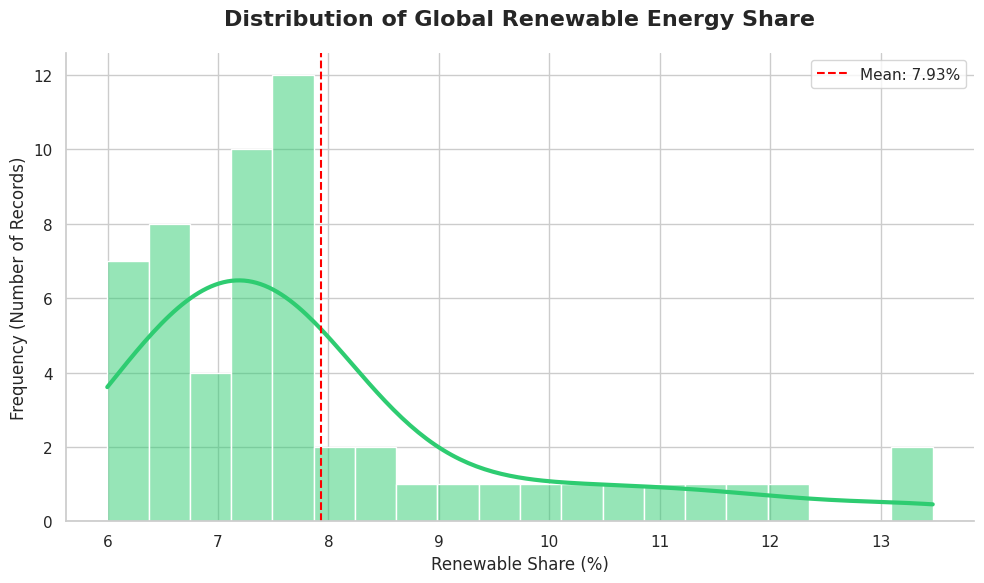

In [12]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot
plot = sns.histplot(
    world_data,
    x="Renewable_Share",
    kde=True,
    color="#2ecc71",   
    bins=20,           
    line_kws={'linewidth': 3}
)

# Labels and title
plt.title('Distribution of Global Renewable Energy Share', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Renewable Share (%)', fontsize=12)
plt.ylabel('Frequency (Number of Records)', fontsize=12)

# Vertical line for the mean
mean_val = world_data['Renewable_Share'].mean()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}%')
plt.legend()

# Layout clean-up
sns.despine()
plt.tight_layout()

plt.show();

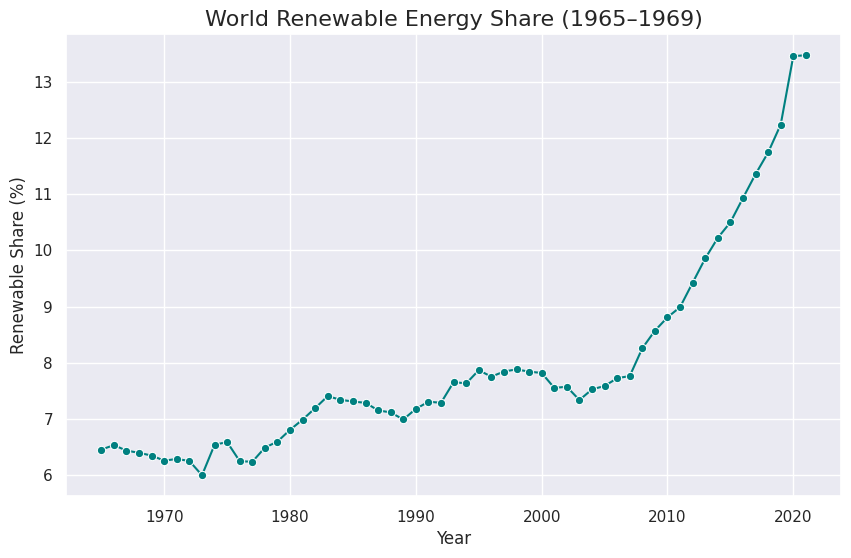

In [13]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(10, 6))
plot = sns.lineplot(world_data, x='Year', y='Renewable_Share', marker='o', color='teal')

plot.set_title('World Renewable Energy Share (1965–1969)', fontsize=16)
plot.set_xlabel('Year', fontsize=12)
plot.set_ylabel('Renewable Share (%)', fontsize=12)
plt.show();

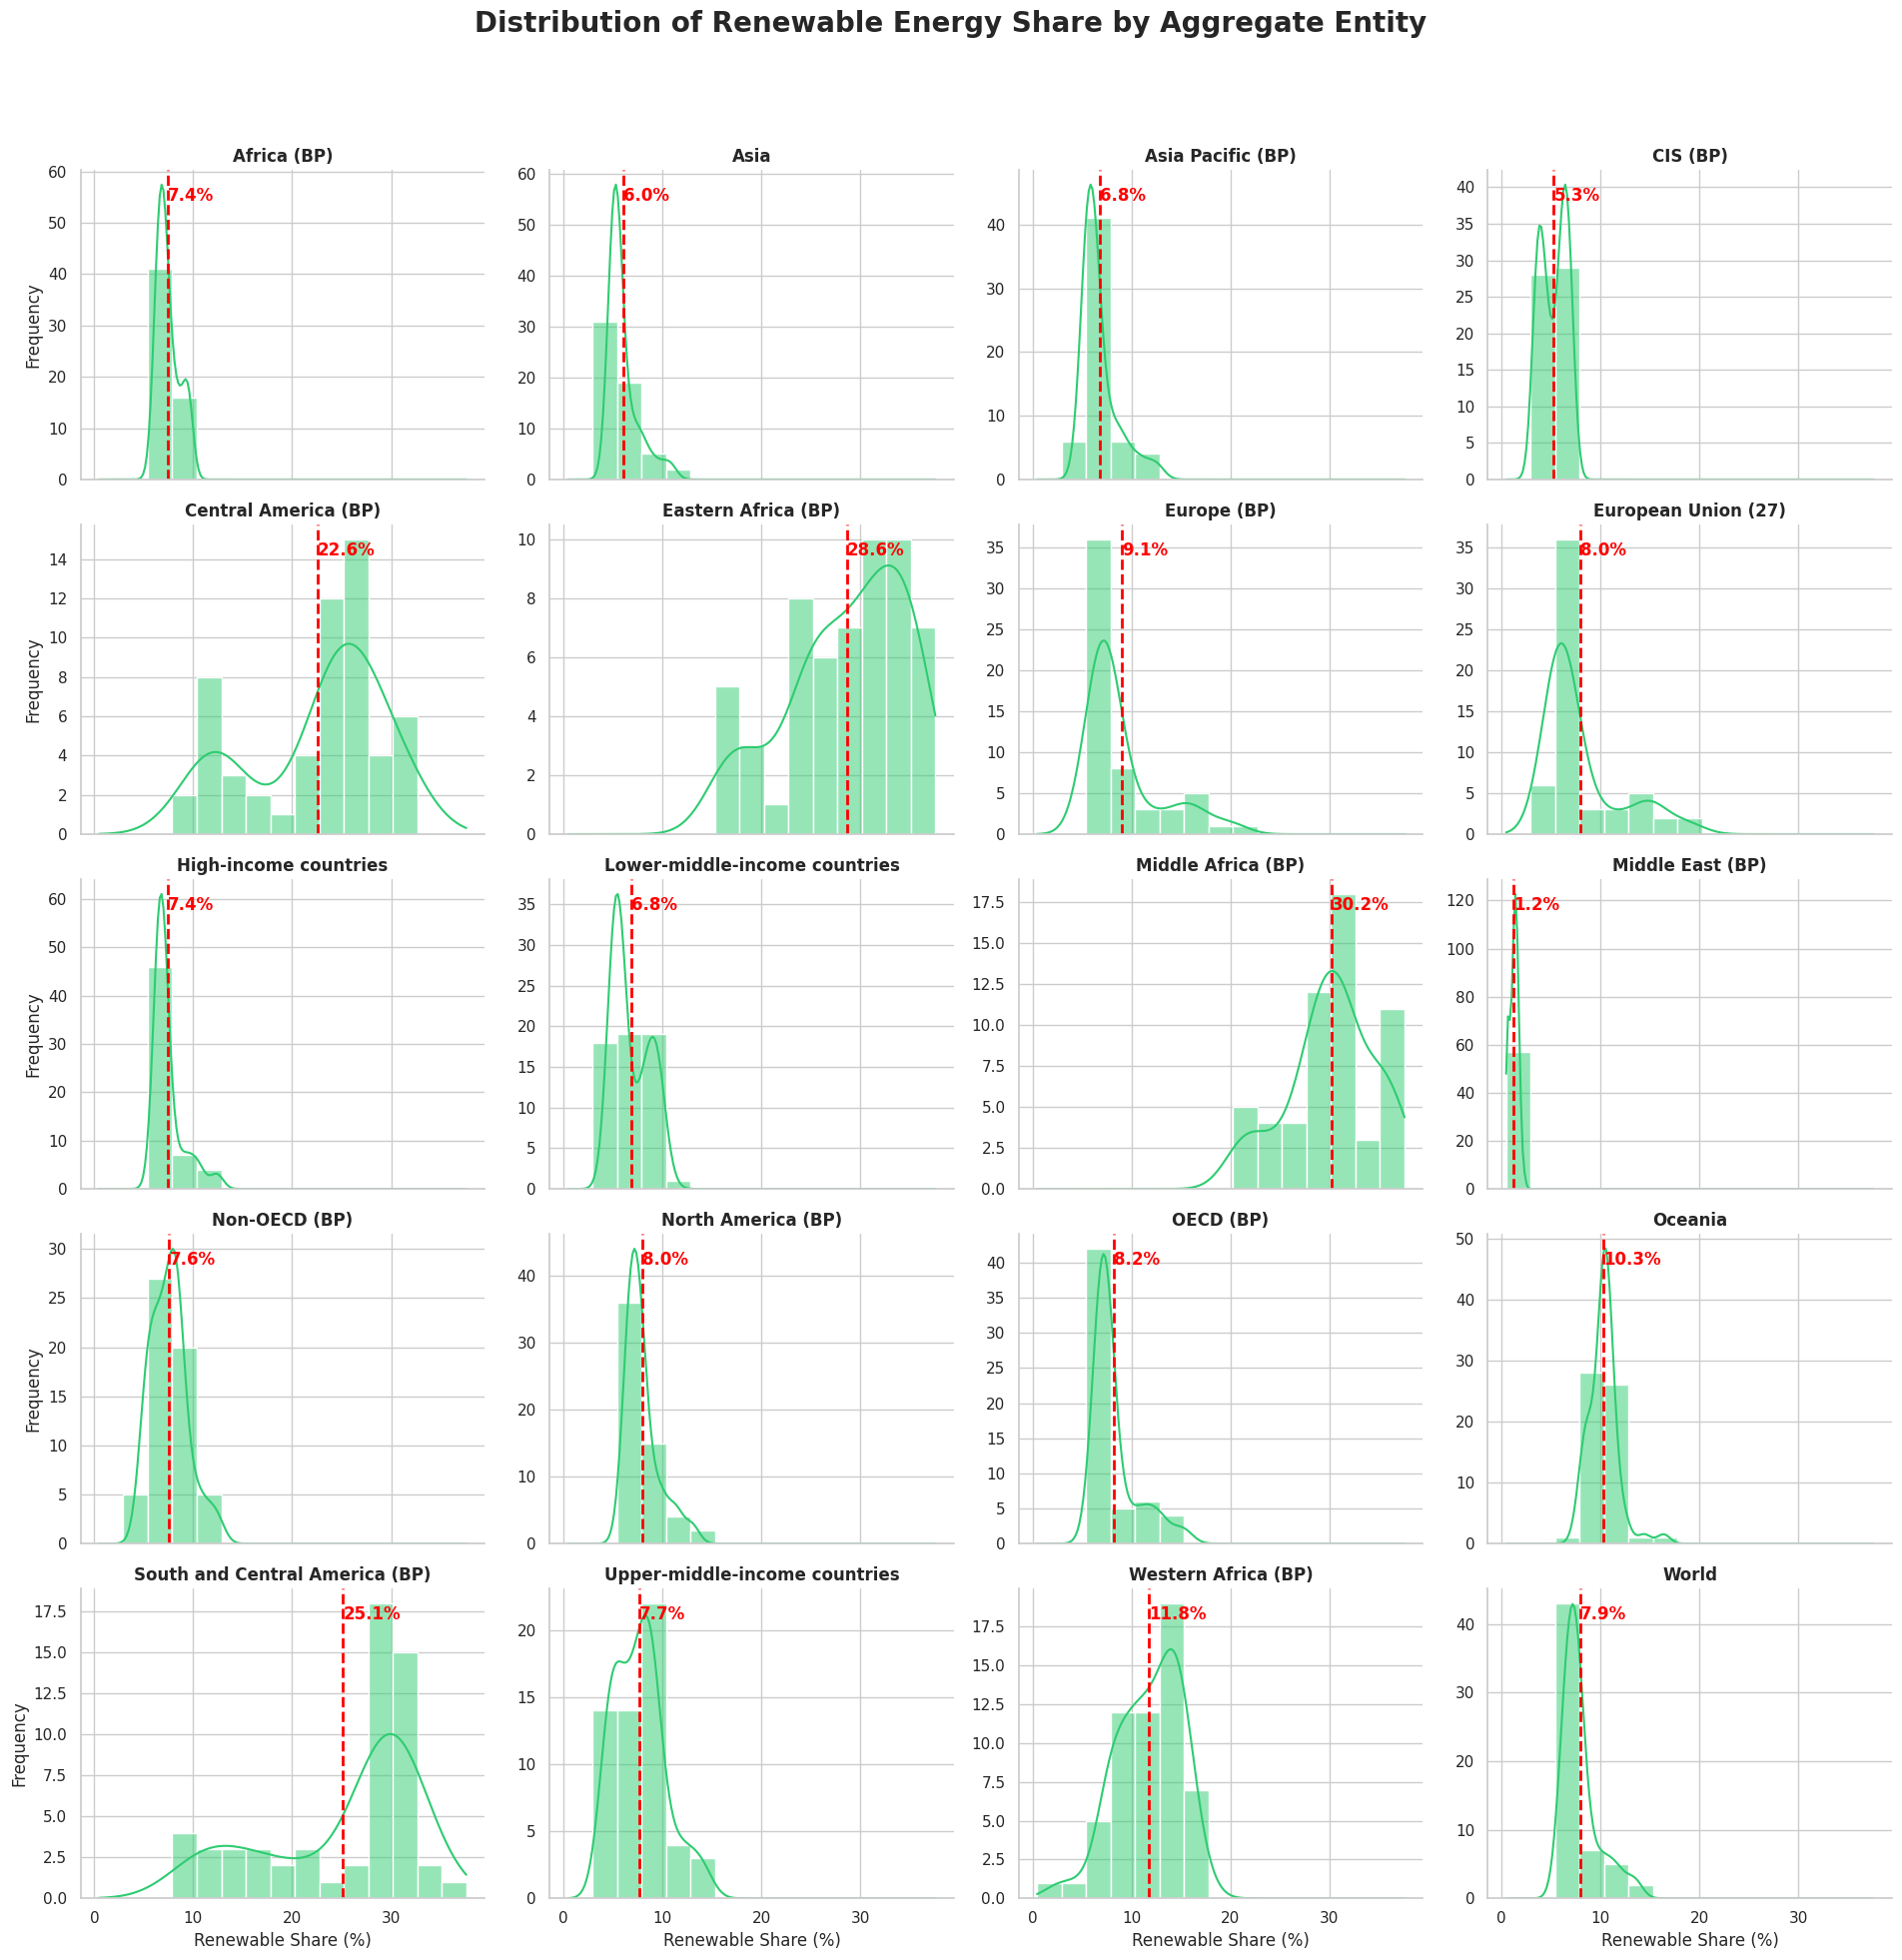

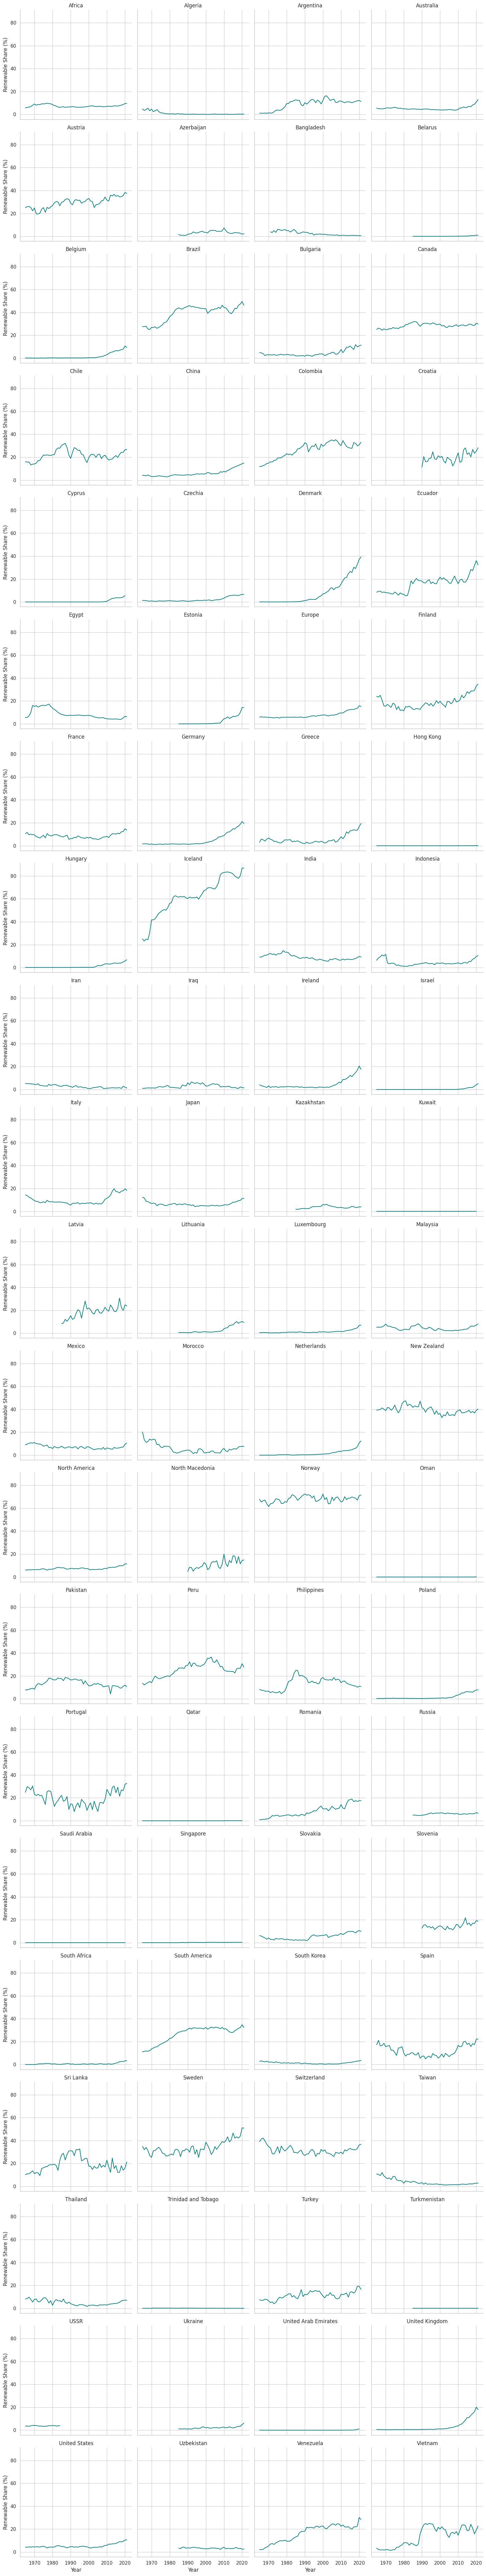

In [15]:
# Initializing the grid
grid = sns.FacetGrid(countries_data, col="Entity", col_wrap=4, height=4)

# Mapping the lineplot function onto the grid
grid.map(sns.lineplot, "Year", "Renewable_Share", color="teal")

# Titles and labels
grid.set_titles("{col_name}")
grid.set_axis_labels("Year", "Renewable Share (%)")

plt.xlabel('')
plt.show()

#### Time series trend analysis

In [16]:
# Rate of Acceleration (Year-over-Year % Change)
# We use .diff() to see the absolute percentage point increase
world_data['YoY_Increase'] = world_data['Renewable_Share'].diff()

# Rolling Average (10-Year window)
world_data['10yr_Avg'] = world_data['Renewable_Share'].rolling(window=10).mean()

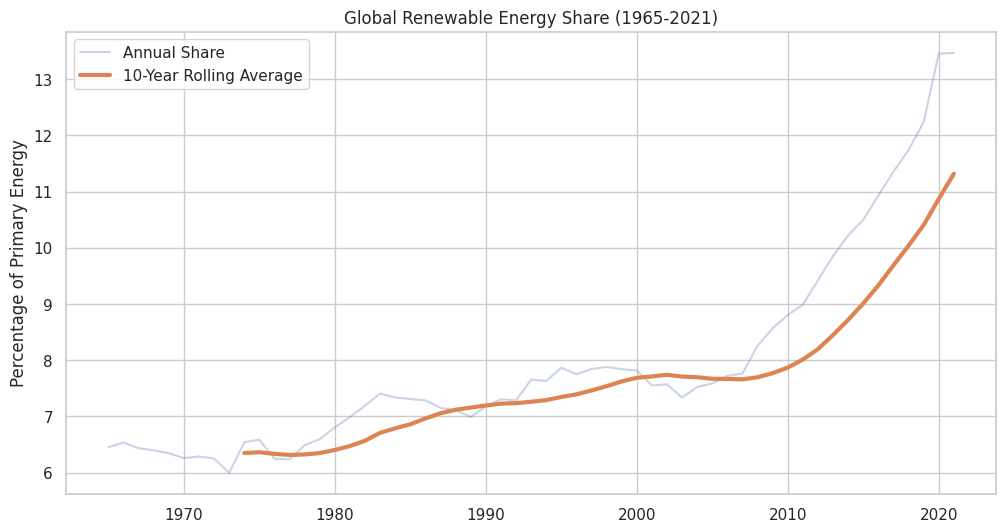

In [17]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

# Plotting the annual share
sns.lineplot(data=world_data, x='Year', y='Renewable_Share', 
             label='Annual Share', alpha=0.3)

# Plotting the 10-year rolling average
sns.lineplot(data=world_data, x='Year', y='10yr_Avg', 
             label='10-Year Rolling Average', linewidth=3)

plt.title('Global Renewable Energy Share (1965-2021)')
plt.ylabel('Percentage of Primary Energy')
plt.xlabel('')
plt.legend()
plt.show()

#### Breakdown:

1. The Two Lines
- **Annual Share (Light Blue)**: This is the "raw" data. You’ll notice it is "jaggy"—it goes up and down slightly from year to year.   
These fluctuations are often caused by natural factors; for example, a very dry year globally can reduce hydropower output, causing the renewable share to dip even if more solar panels were installed that year.

- **10-Year Rolling Average (Bold Orange)**: This line calculates the average of the previous 10 years at every point. It effectively "filters out" the yearly noise to show the underlying structural trend. When the orange line slopes upward, it means the world is making a permanent shift in its energy infrastructure.

2. Key Historical Phases
- **The Plateau (1970 – 2000)**: For nearly 30 years, the renewable share was relatively stagnant, hovering between 6% and 8%.  
During this era, renewables were dominated by traditional large-scale hydropower, and solar/wind technology was still too expensive for mass adoption.

- **The Inflection Point (Circa 2005 - 2010)**: Notice how the orange line starts to curve upward more steeply here.  
This correlates with the massive drop in the cost of solar and wind power and the beginning of more aggressive global climate policies.

- **The "Hockey Stick" Growth (2015 – 2021):** The final section shows an almost vertical surge. By 2021, the share reaches over 13%.  
The gap between the 1965 starting point (~6%) and the 2021 ending point shows that the global renewable share has more than doubled.

3. What the "Lag" in the lines mean
- The orange line stops before the blue line on the left side and sits "behind" it on the right.

- On the left, the orange line needs 10 years of data to start calculating, thus it begins around 1975

- On the right, as it is a 10-year average, it is "slower" to react. But, since the blue line is much higher than the orange line at the end, is a very positive sign indicating that the current progress is significantly faster than the average progress over the last decade.

**In short, the graph proves that the "Green Transition" is going through measurable acceleration. It took 40 years to grow by 2% but in the last decade it has leaped by 5%**

#### Top 10 countries in 2021

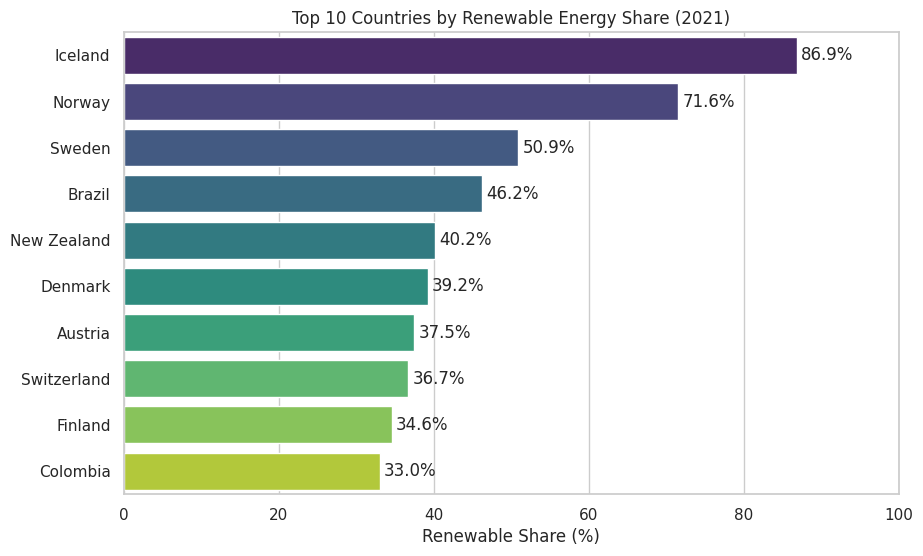

In [18]:
# Filter for the latest year (2021), Sort by the Renewable_Share column, Take the top 10 rows

top_10_2021 = countries_data[countries_data['Year'].dt.year == 2021].sort_values(by='Renewable_Share', ascending=False).reset_index(drop=True).head(10)
top_10_2021 = top_10_2021[['Entity', 'Renewable_Share']]

# -- Barplot
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=top_10_2021, 
    x='Renewable_Share', 
    y='Entity', 
    palette='viridis'
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Top 10 Countries by Renewable Energy Share (2021)')
plt.xlabel('Renewable Share (%)')
plt.ylabel('')
plt.xlim(0, 100)

plt.show();

#### Breakdown
- **Leader of the Pack**: Iceland is the clear global leader, with a staggering 86.9% of its energy coming from renewables.  
This is largely due to its unique geography, which allows for massive production of geothermal and hydroelectric power.

- **The Nordic Dominance**: Four of the top ten countries are Nordic (Iceland, Norway, Sweden, and Finland).  
Their success is typically attributed to a combination of natural water resources for hydropower and strong government policies.

- **Regional Diversity**: While European nations dominate the list, South America is well-represented by Brazil (46.2%) and Colombia (33.0%), both of which rely heavily on hydropower.

- **The 50% Threshold**: Only the top three countries—Iceland, Norway, and Sweden—sourced more than half of their total energy from renewables in 2021.

#### Catch-up Analysis (The "Fastest Climbers")

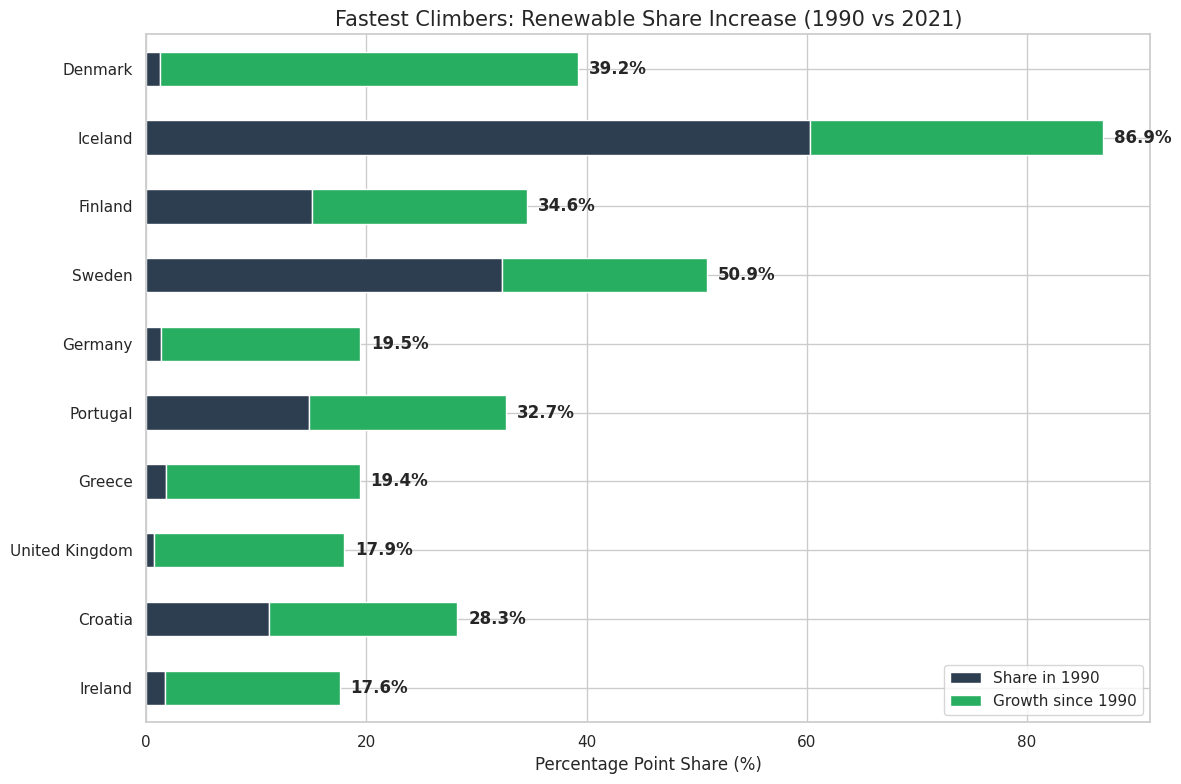

In [19]:
# Get data for 1990 and 2021
data_1990 = countries_data[countries_data['Year'].dt.year == 1990][['Entity', 'Renewable_Share']]
data_2021 = countries_data[countries_data['Year'].dt.year == 2021][['Entity', 'Renewable_Share']]

# Merge them together on the Entity name
growth_df = pd.merge(data_1990, data_2021, on='Entity', suffixes=('_1990', '_2021'))

# Calculate the absolute growth (Percentage point increase)
growth_df['Growth'] = growth_df['Renewable_Share_2021'] - growth_df['Renewable_Share_1990']

# Sort to find the biggest climbers
fastest_climbers = growth_df.sort_values(by='Growth', ascending=False).head(10)

# Set the index to Entity for easier plotting
fastest_climbers.set_index('Entity', inplace=True)

# Plotting
ax = fastest_climbers[['Renewable_Share_1990', 'Growth']].plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 8), 
    color=['#2c3e50', '#27ae60'] # Dark blue for base, Green for growth
)

# Adding labels for the total 2021 value
for i, total in enumerate(fastest_climbers['Renewable_Share_2021']):
    ax.text(total + 1, i, f'{total:.1f}%', va='center', fontweight='bold')

plt.title('Fastest Climbers: Renewable Share Increase (1990 vs 2021)', fontsize=15)
plt.xlabel('Percentage Point Share (%)')
plt.ylabel('')
plt.legend(['Share in 1990', 'Growth since 1990'], loc='lower right')
plt.gca().invert_yaxis() # Highest climber at the top
plt.tight_layout()
plt.show()

#### Breakdown

1. **The "Clean Slates" (High Growth)**
- Countries like Denmark, Germany, and the United Kingdom started with almost zero renewable energy in 1990 (the dark blue slivers are very small).

- Denmark is the standout "climber," adding nearly 38 percentage points to its mix in three decades.

- Germany and the UK show similar patterns, where nearly their entire current renewable capacity was built from scratch since 1990.

2. **The "Early Adopters" (High Baseline)**
- Iceland, Sweden, and Norway (though Norway isn't on this specific "Fastest Climbers" list, it fits the profile) already had significant renewable infrastructure in 1990, mostly from hydropower and geothermal energy.

- Iceland already had a massive 60% share in 1990. Their green bar shows they didn't just "rest on their laurels" but pushed even further to reach nearly 87%.

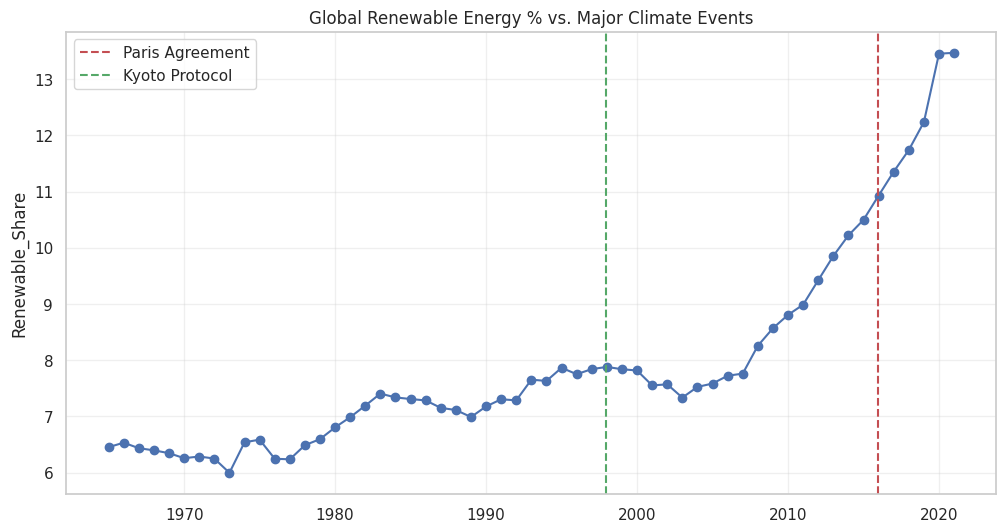

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(world_data['Year'], world_data['Renewable_Share'], marker='o')

# Adding Event Correlations
plt.axvline(x=pd.Timestamp('2015-12-12'), color='r', linestyle='--', label='Paris Agreement')
plt.axvline(x=pd.Timestamp('1997-12-11'), color='g', linestyle='--', label='Kyoto Protocol')

plt.title('Global Renewable Energy % vs. Major Climate Events')
plt.ylabel('Renewable_Share')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Breakdown

Key Event Correlations  
- **The Kyoto Protocol (Green Line)**: Interestingly, the data doesn't spike immediately after 1998. Statistically, this shows a lag effect.  
It took nearly a decade for the policies established in Kyoto to manifest as actual physical infrastructure (wind farms and solar arrays) reflected in the global energy mix.

- **The Paris Agreement (Red Line)**: Unlike Kyoto, the trend was already accelerating when this was signed.  
The Paris Agreement acted more like "fuel on the fire," coinciding with the moment renewable technologies became cost-competitive with coal and gas.

- **The 2020 Peak**: Sharpest jump right around 2020. As we discussed earlier, this is a "COVID anomaly"—total energy demand dropped globally, but because renewables have low marginal costs (the sun and wind are free), they kept running while fossil fuel plants were throttled back, causing their percentage share to skyrocket.

In [21]:
# Calculate the percentage point increase year-over-year
world_data = world_data.sort_values('Year')
world_data['Annual_Increase'] = world_data['Renewable_Share'].diff()

# Profile: Average growth before and after 2015 (Paris Agreement)
pre_paris = world_data[world_data['Year'] < '2015-01-01']['Annual_Increase'].mean() *100
post_paris = world_data[world_data['Year'] >= '2015-01-01']['Annual_Increase'].mean() *100

print(f"Avg Yearly Increase Pre-2015 (Before Paris Agreement): {pre_paris:.3f}%")
print(f"Avg Yearly Increase Post-2015 (After Paris Agreement): {post_paris:.3f}%")

Avg Yearly Increase Pre-2015 (Before Paris Agreement): 7.689%
Avg Yearly Increase Post-2015 (After Paris Agreement): 46.410%


#### Pre-2015 (7.689%)  
This represents "Linear Growth." Before the Paris Agreement, renewables were increasing their share of the global energy pie by a modest amount each year.  
At this rate, it would have taken many decades to displace fossil fuels. This was the era of expensive solar panels and early-stage wind technology.

#### Post-2015 (46.410%)  
This represents "Explosive Acceleration." The rate at which renewables are gaining ground has increased by more than 6 times compared to the previous period.

## Linear Trajectory Analysis: Projecting the Horizon for 100% Renewable Integration

In [22]:
def forecast_100_percent(data):
    results = []
    entities = data['Entity'].unique()

    for entity in entities:
        # Optimization: Filter for recent years (e.g., >= 2005) to get current velocity
        subset = data[(data['Entity'] == entity) & (data['Year'] >= '2005-01-01')].dropna(subset=['Renewable_Share'])
        
        if len(subset) < 5: continue 

        X = pd.to_datetime(subset['Year']).map(pd.Timestamp.toordinal).values.reshape(-1, 1)
        y = subset['Renewable_Share'].values

        model = LinearRegression()
        model.fit(X, y)

        slope = model.coef_[0]
        intercept = model.intercept_

        # Solve for 100: 100 = slope * x + intercept -> x = (100 - intercept) / slope
        if slope <= 0:
            pred_year = "Trend Negative"
        else:
            target_ordinal = (100 - intercept) / slope
            
            if target_ordinal > 3652059: # Beyond Python's datetime limit
                pred_year = "Beyond 9999"
            else:
                pred_year = pd.Timestamp.fromordinal(int(target_ordinal)).year
        
        results.append({
            'Entity': entity, 
            '100% Target Year': pred_year, 
            'Current %': round(y[-1], 2)
        })

    # Create DataFrame and sort by the predicted year
    res_df = pd.DataFrame(results)
    
    # Sorting logic for mixed types (Numbers vs "Beyond 9999")
    res_df['sort_val'] = pd.to_numeric(res_df['100% Target Year'], errors='coerce').fillna(10000)
    res_df = res_df.sort_values('sort_val').drop(columns=['sort_val'])
    
    return res_df

# Execute and view
forecast_100_df = forecast_100_percent(countries_data).reset_index(drop=True)

In [23]:
print("Forecase of when said countries will reach 100% - Sorted on Year column")
display(forecast_100_df.head(10))
print("\n")

print("Forecase of when said countries will reach 100% - Sorted on Current% column")
forecast_100_df.sort_values(by="Current %",ascending=False).head(10).reset_index(drop=True)

Forecase of when said countries will reach 100% - Sorted on Year column


,Entity,100% Target Year,Current %
0,Iceland,2045,86.870
1,Denmark,2056,39.250
2,Sweden,2076,50.920
3,Portugal,2081,32.700
4,Ecuador,2088,32.350
5,Finland,2090,34.610
6,United Kingdom,2092,17.950
7,Ireland,2101,17.580
8,Germany,2104,19.450
9,Greece,2111,19.390




Forecase of when said countries will reach 100% - Sorted on Current% column


,Entity,100% Target Year,Current %
0,Iceland,2045,86.870
1,Norway,2273,71.560
2,Sweden,2076,50.920
3,Brazil,2311,46.220
4,New Zealand,2278,40.220
5,Denmark,2056,39.250
6,Austria,2141,37.480
7,Switzerland,2147,36.720
8,Finland,2090,34.610
9,Colombia,Trend Negative,33.020


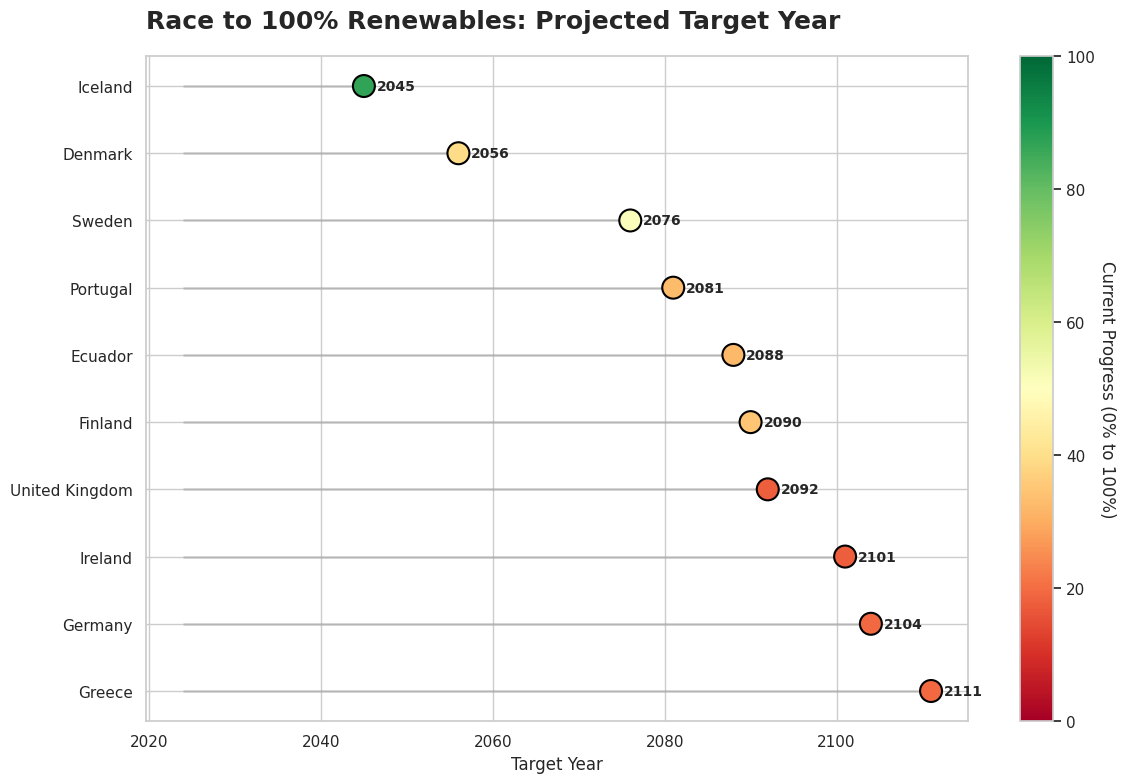

In [24]:
def plot_lollipop_forecast(df, top_n=10):
    # 1. Prep data
    plot_df = df.copy()
    plot_df['100% Target Year'] = pd.to_numeric(plot_df['100% Target Year'], errors='coerce')
    plot_df = plot_df.dropna(subset=['100% Target Year'])
    plot_df = plot_df.sort_values('100% Target Year').head(top_n)
    plot_df = plot_df.iloc[::-1]

    # 2. Setup the figure
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")
    
    # 3. Draw the 'Sticks'
    plt.hlines(y=plot_df['Entity'], 
               xmin=2024, 
               xmax=plot_df['100% Target Year'], 
               color='grey', alpha=0.3, linewidth=2)
    
    # 4. Draw the 'Candy' (The dots)
    # cmap='RdYlGn' goes Red -> Yellow -> Green
    # vmin/vmax fixes the scale so 0 is red and 100 is green
    scatter = plt.scatter(plot_df['100% Target Year'], 
                          plot_df['Entity'], 
                          s=250, 
                          c=plot_df['Current %'], 
                          cmap='RdYlGn', 
                          vmin=0, 
                          vmax=100, 
                          edgecolors="black", 
                          linewidth=1.5, 
                          zorder=3)

    # 5. Add a Colorbar with fixed limits
    cbar = plt.colorbar(scatter)
    cbar.set_label('Current Progress (0% to 100%)', rotation=270, labelpad=15)

    # 6. Formatting
    plt.title('Race to 100% Renewables: Projected Target Year', loc='left', fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Target Year', fontsize=12)
    plt.ylabel('') 
    
    # Label the years
    for i, row in plot_df.iterrows():
        plt.text(row['100% Target Year'] + 1.5, row['Entity'], 
                 f"{int(row['100% Target Year'])}", 
                 va='center', fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.show()

# Run the function
plot_lollipop_forecast(forecast_100_df)

#### Breakdown

- Iceland is the frontrunner with a projected target year of 2045.  
    - This is supported by its extremely high current progress (over 86%), combined with a positive growth trajectory.

- Countries like Denmark (2056) and Sweden (2076) follow.  
    - Note that Denmark is projected to finish earlier than Sweden despite starting from a lower current percentage.  
    - This is because the slope (rate of change) in Denmark's recent data is much steeper than Sweden's.

**Because LinearRegression treats energy transitions as a simple addition problem** ($y = mx + b$), **it ignores several real-world variables**:  

- Linear models assume it is just as easy to go from 90% to 100% as it was to go from 10% to 20%.  
    - In reality, the final 10% often requires expensive breakthroughs in long-term battery storage or hydrogen for heavy industry. A linear model will likely be too optimistic for countries nearing the finish line.  
- There is an infinite growth fallacy associated with linear models, they just unable to recognize a ceiling.  
    - If a country has a massive growth spike (like the sharp spike post-2015 seen in this dataset), the model might predict they hit 100% in just a few years, which is physically and economically impossible.  
-The sharp jump in global energy chart around 2020 was an outlier.  
    - This was largely a "COVID anomaly" where total energy demand dropped, making the renewable percentage look higher. A linear model trained on this data might perceive a "velocity" that isn't sustainable, leading to skewed target years.  
- Policy changes do not yield instantaneous results  
    - As seen with the Kyoto Protocol and Paris Agreement, there is often a significant delay between signing a treaty and seeing a change in the data. A linear model cannot account for future policy changes or "sudden shifts" in technology; it only knows what has happened in the past.

In [25]:
# 1. Isolate the categorical string results
beyond_df = forecast_100_df[forecast_100_df['100% Target Year'] == 'Beyond 9999'].reset_index(drop=True)
negative_df = forecast_100_df[forecast_100_df['100% Target Year'] == 'Trend Negative'].reset_index(drop=True)

# 2. Isolate the numeric results for sorting
# pd.to_numeric with 'coerce' turns strings like "Beyond 9999" into NaN, allowing us to drop them
numeric_mask = pd.to_numeric(forecast_100_df['100% Target Year'], errors='coerce').notna()
numeric_df = forecast_100_df[numeric_mask].copy()

# Ensure the years are treated as integers for proper sorting
numeric_df['100% Target Year'] = numeric_df['100% Target Year'].astype(int)
numeric_df = numeric_df.sort_values(by='100% Target Year')

# 3. Extract the Top 10 and Last 10
top_10_df = numeric_df.head(10)
last_10_df = numeric_df.tail(10).reset_index(drop=True)

# 4. Print the results cleanly
display("TOP 10: EARLIEST TARGET YEARS")
display(top_10_df)
print("\n")

display("LAST 10: LATEST NUMERIC TARGET YEARS")
display(last_10_df)
print("\n")

display("STAGNANT: BEYOND 9999")
display(beyond_df)
print("\n")

display("FAILING: TREND NEGATIVE")
display(negative_df)
print("\n")


'TOP 10: EARLIEST TARGET YEARS'

,Entity,100% Target Year,Current %
0,Iceland,2045,86.870
1,Denmark,2056,39.250
2,Sweden,2076,50.920
3,Portugal,2081,32.700
4,Ecuador,2088,32.350
5,Finland,2090,34.610
6,United Kingdom,2092,17.950
7,Ireland,2101,17.580
8,Germany,2104,19.450
9,Greece,2111,19.390


'LAST 10: LATEST NUMERIC TARGET YEARS'

,Entity,100% Target Year,Current %
0,South Africa,2530,3.410
1,Ukraine,2618,6.100
2,Canada,2633,29.890
3,Africa,2641,9.560
4,India,2795,9.310
5,Venezuela,3059,28.430
6,Taiwan,3101,3.040
7,Belarus,3716,0.970
8,United Arab Emirates,4208,1.020
9,Russia,9228,6.620


'STAGNANT: BEYOND 9999'

,Entity,100% Target Year,Current %
0,Hong Kong,Beyond 9999,0.110
1,Egypt,Beyond 9999,6.230
2,Saudi Arabia,Beyond 9999,0.020
3,Singapore,Beyond 9999,0.310
4,Qatar,Beyond 9999,0.080
5,Oman,Beyond 9999,0.220
6,Kuwait,Beyond 9999,0.040
7,Algeria,Beyond 9999,0.260
8,Turkmenistan,Beyond 9999,0.010


'FAILING: TREND NEGATIVE'

,Entity,100% Target Year,Current %
0,Colombia,Trend Negative,33.020
1,Azerbaijan,Trend Negative,2.200
2,Philippines,Trend Negative,10.900
3,Pakistan,Trend Negative,10.620
4,Peru,Trend Negative,27.740
5,Iran,Trend Negative,1.290
6,Kazakhstan,Trend Negative,3.990
7,Iraq,Trend Negative,1.500
8,Bangladesh,Trend Negative,0.650
9,Argentina,Trend Negative,11.330


1. The Leaders: Success via Early Adoption and High Velocity
The top entities share a common trait: a high "Recent Trend" velocity that overcomes the gap to 100%.

Iceland (2045): This is the "Gold Standard." With a Current % of 86.87, Iceland has the lowest distance to travel. Because their current share is so high and their growth remains positive, the linear model sees a very short path to completion.

Denmark (2056): Despite having a lower starting point (39.25%) than Sweden, Denmark is projected to finish sooner. This indicates that Denmark's slope (annual increase) since 2005 is significantly steeper, likely due to aggressive offshore wind expansion.

Sweden, Portugal, and Ecuador: These countries represent steady, mid-range transitions. They have surpassed the "1/3rd mark" (32%+), and their linear momentum is strong enough to cross the finish line within this century.

2. The "Stagnant" Group: Beyond 9999
When you see "Beyond 9999," it typically indicates an entity with a mathematically negligible growth rate.

The Gulf States (Saudi Arabia, Qatar, Kuwait, Oman): These entities have current renewable shares near zero (e.g., Saudi Arabia at 0.02%). Because their historical growth has been so slow, the linear model calculates that it would take thousands of years to reach 100% at their current "velocity."

City-States (Hong Kong, Singapore): With very low shares (under 1%) and limited land for massive solar or wind farms, their linear trend shows almost no progress toward the target.

3. The "Trend Negative" Group: The Most Critical Failure
From a Data Science perspective, "Trend Negative" is more alarming than "Beyond 9999." It means that between 2005 and 2021, these entities actually saw their Renewable Share decrease.

South America & Regional Examples (Colombia, Peru, Sri Lanka): These regions often rely heavily on Hydropower. If a country experiences severe droughts or if their total energy demand grows faster than they can build new renewables, their percentage share actually drops.

The Trap: Colombia has a high 33.02% share, but because the trend is negative, the linear model cannot calculate a "Target Year"—it sees the country moving away from the goal.

Why this happens (The Linear Flaw)
This list perfectly illustrates the flaw of Linear Regression in energy modeling:

It ignores potential: It doesn't know Saudi Arabia is currently building some of the world's largest solar plants; it only sees the near-zero historical data.

It punishes hydro-dependency: Countries like Sri Lanka or Colombia might have "bad years" due to weather, which the linear model interprets as a permanent trend of failure.